--- DATASET LOADED ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Features selected for Clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


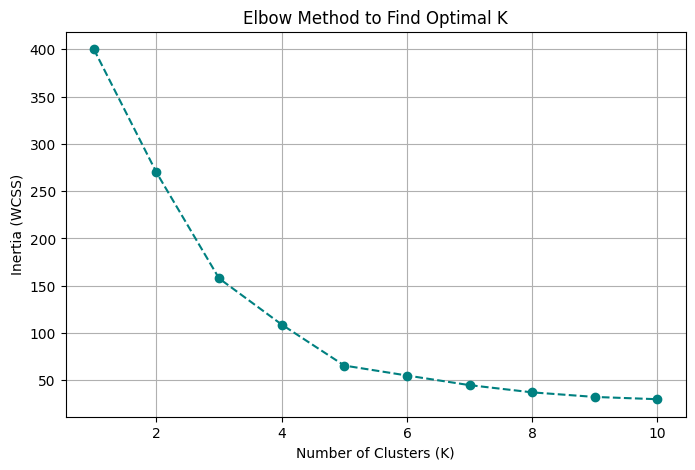

Observation: The 'Elbow' (bend) typically appears at K=5.


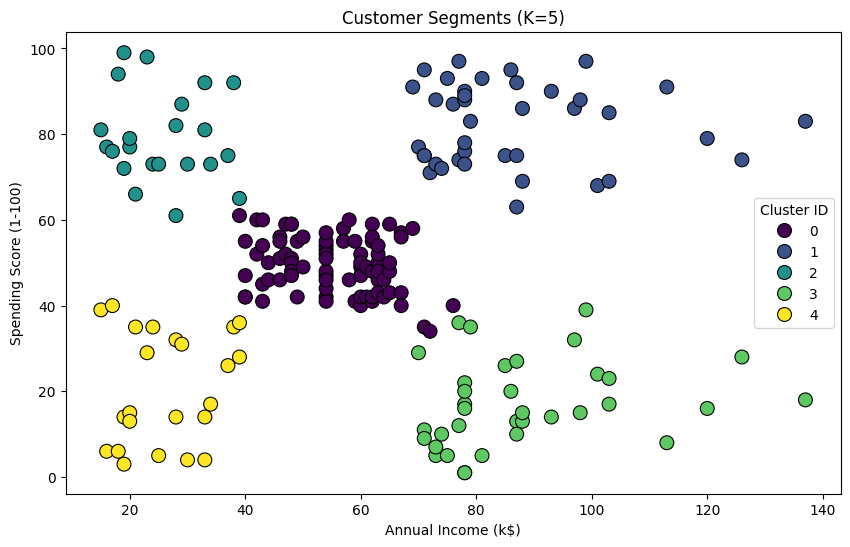


SUCCESS: Segmented dataset saved as 'Mall_Customers_Segmented.csv'

--- CLUSTER CENTERS (Interpretation) ---


,Income,Spending,Cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# 1. Load Dataset (Bulletproof Link)
# Using a reliable repository for the Mall Customers dataset
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

print("--- DATASET LOADED ---")
display(df.head())

# 2. Data Preprocessing
# We only need 'Annual Income' and 'Spending Score' for this segmentation
# We drop CustomerID as it has no pattern information
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(f"\nFeatures selected for Clustering:\n{X.head()}")

# 3. Feature Scaling
# KMeans uses distance, so scaling is crucial
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Finding Optimal K (Elbow Method)
inertia_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

print("Observation: The 'Elbow' (bend) typically appears at K=5.")

# 5. Train KMeans Model (K=5)
# Based on the elbow plot, we choose 5 clusters
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add cluster labels back to original data
df['Cluster'] = clusters

# 6. Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    edgecolor='black'
)
plt.title('Customer Segments (K=5)')
plt.legend(title='Cluster ID')
plt.show()

# 7. Save Segmented Data
df.to_csv("Mall_Customers_Segmented.csv", index=False)
print("\nSUCCESS: Segmented dataset saved as 'Mall_Customers_Segmented.csv'")

# 8. Cluster Interpretation (Centroids)
# Inverse transform centroids to see real values
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=['Income', 'Spending'])
centroid_df['Cluster'] = range(5)
print("\n--- CLUSTER CENTERS (Interpretation) ---")
display(centroid_df)